In [2]:
import pandas as pd
import numpy as np
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import seaborn as sns
from src.dataloading import load_data
from src.eda import check_missing_values,handle_missing_values
sns.set_style("whitegrid")

In [11]:
df = pd.read_csv("../data/raw/MachineLearningRating_v3.txt", sep="|",
    na_values=[' ', '', 'NA'])
df

C:\Users\bemnet\AppData\Local\Temp\ipykernel_18800\2344027165.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/MachineLearningRating_v3.txt", sep="|",


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000093,31520,389,2015-04-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000094,31520,389,2015-06-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000095,31520,389,2015-08-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000096,31519,389,2014-07-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,No excess,Passenger Liability,Passenger Liability,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,2.315000,0.0


In [12]:
print(df.shape)
# print(df.dtypes)

(1000098, 52)


In [13]:
categorical_cols = [
    'IsVATRegistered',
    'Citizenship',
    'LegalType',
    'Title',
    'Language',
    'Bank',
    'AccountType',
    'MaritalStatus',
    'Gender',
    'Country',
    'Province',
    'PostalCode',
    'MainCrestaZone',
    'SubCrestaZone',
    'ItemType',
    'mmcode',
    'VehicleType',
    'make',
    'Model',
    'bodytype',
    'AlarmImmobiliser',
    'TrackingDevice',
    'NewVehicle',
    'WrittenOff',
    'Rebuilt',
    'Converted',
    'CrossBorder',
    'TermFrequency',
    'ExcessSelected',
    'CoverCategory',
    'CoverType',
    'CoverGroup',
    'Section',
    'Product',
    'StatutoryClass',
    'StatutoryRiskType'
]

In [14]:
numerical_cols = [
    'UnderwrittenCoverID',
    'PolicyID',
    'RegistrationYear',
    'Cylinders',
    'cubiccapacity',
    'kilowatts',
    'NumberOfDoors',
    'CustomValueEstimate',
    'CapitalOutstanding',
    'NumberOfVehiclesInFleet',
    'SumInsured',
    'CalculatedPremiumPerTerm',
    'TotalPremium',
    'TotalClaims'
]

In [15]:
date_cols = [
    'TransactionMonth',
    'VehicleIntroDate'
]

## Handle Missing Values

In [16]:
 # Missing values summary
missing_summary = check_missing_values(df)

print("\nMissing Value Summary:")
display(missing_summary)

# Handle missing values
df = handle_missing_values(
    df,
    numerical_cols,
    categorical_cols
)


Missing Value Summary:


,Missing Values,Percentage (%)
NumberOfVehiclesInFleet,1000098,100.000000
CrossBorder,999400,99.930207
CustomValueEstimate,779642,77.956560
WrittenOff,641901,64.183810
Converted,641901,64.183810
Rebuilt,641901,64.183810
NewVehicle,153295,15.327998
Bank,145961,14.594670
AccountType,40232,4.022806
Gender,9536,0.953507


## Data Validation & Quality Checks

In [20]:
# Check duplicates
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

# Check negative financial values
negative_claims = (
    df['TotalClaims'] < 0
).sum()

negative_premium = (
    df['TotalPremium'] < 0
).sum()

print("Negative Claims:", negative_claims)

print("Negative Premiums:", negative_premium)

Duplicate Rows: 74
Negative Claims: 5
Negative Premiums: 288


Negative premium and claim values were identified in the dataset. These may represent refunds, reversals, policy cancellations, or accounting adjustments. Duplicate checks and validation procedures were performed to improve data reliability before analysis.

In [17]:
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

In [18]:
df['TransactionMonth'] = pd.to_datetime(
    df['TransactionMonth'],
   
    errors='coerce'
)
df['VehicleIntroDate'] = pd.to_datetime(
    df['VehicleIntroDate'],
    errors='coerce'
)

C:\Users\bemnet\AppData\Local\Temp\ipykernel_18800\1319927510.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['VehicleIntroDate'] = pd.to_datetime(


In [19]:
totalclaims_table = pd.DataFrame(
    df['TotalClaims'].describe()
)

# Rename column for cleaner display
totalclaims_table.columns = ['TotalClaims']

# Display table
display(totalclaims_table)

,TotalClaims
count,1.000098e+06
mean,6.486119e+01
std,2.384075e+03
min,-1.200241e+04
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,3.930921e+05


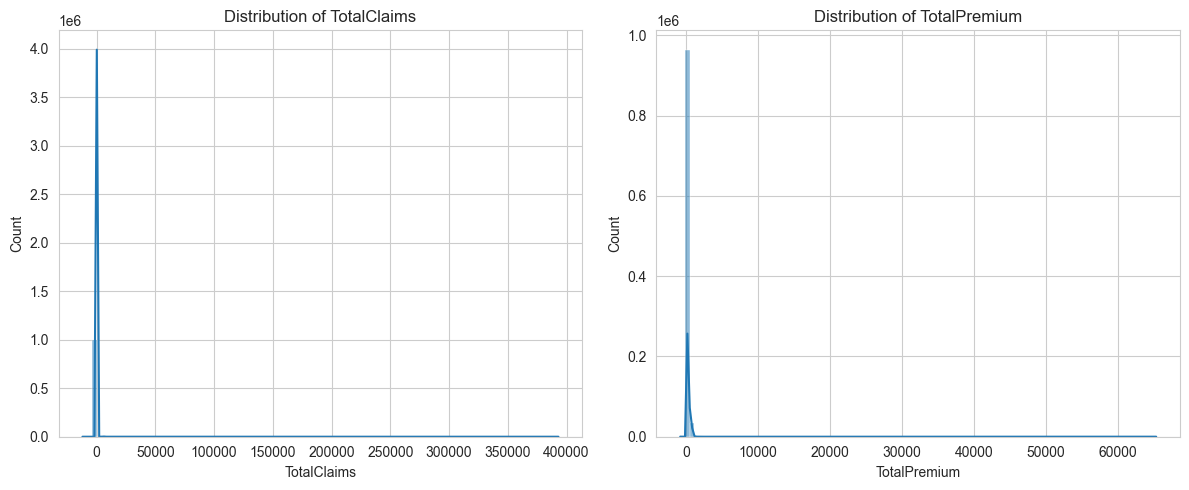

In [49]:
# Create figure
plt.figure(figsize=(12, 5))

# TotalClaims distribution
plt.subplot(1, 2, 1)
sns.histplot(df['TotalClaims'], bins=100, kde=True)
plt.title('Distribution of TotalClaims')
plt.xlabel('TotalClaims')

# TotalPremium distribution
plt.subplot(1, 2, 2)
sns.histplot(df['TotalPremium'], bins=100, kde=True)
plt.title('Distribution of TotalPremium')
plt.xlabel('TotalPremium')

plt.tight_layout()
plt.show()

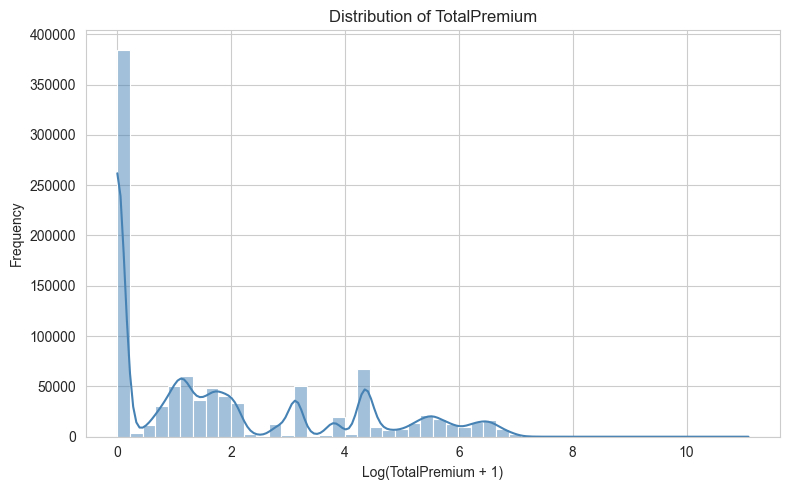

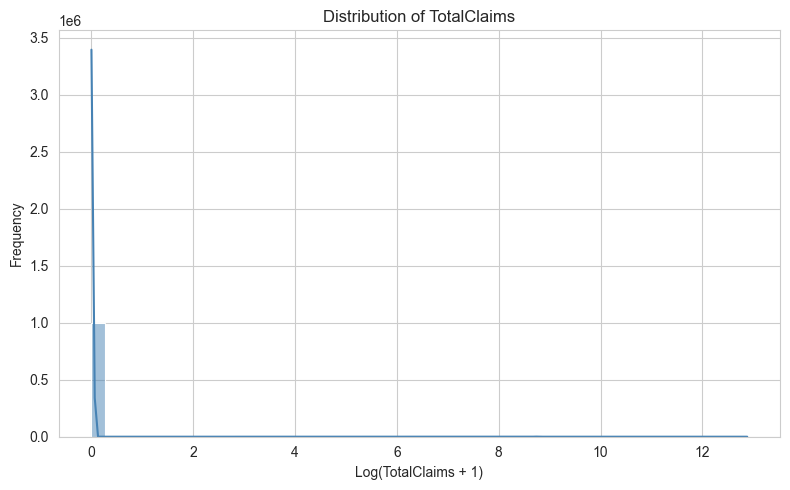

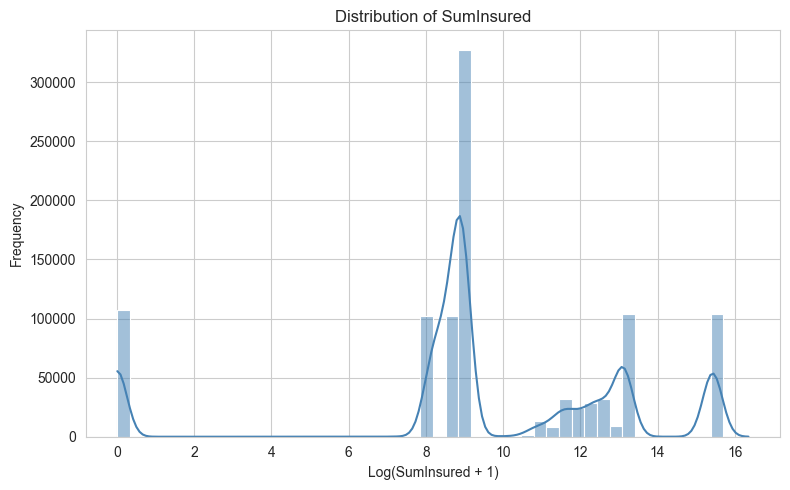

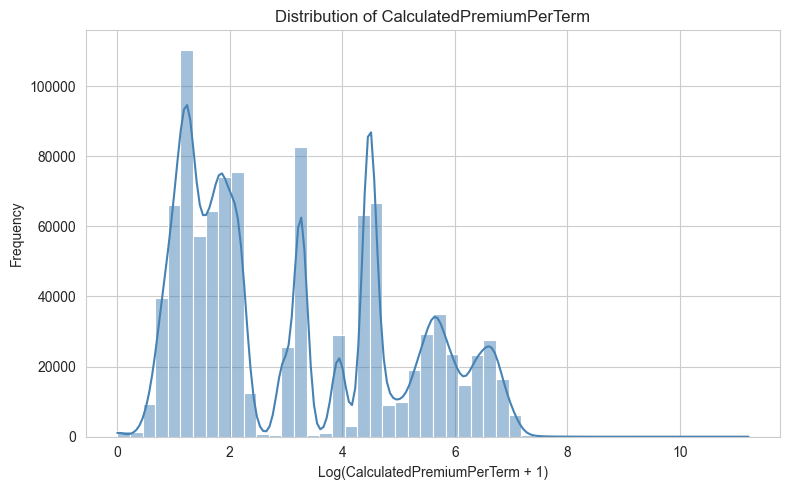

In [52]:
numerical_cols = [
    'TotalPremium',
    'TotalClaims',
    'SumInsured',
    'CalculatedPremiumPerTerm'
]

# Use log transformation for skewed insurance data
for col in numerical_cols:

    plt.figure(figsize=(8,5))

    transformed = np.log1p(
        df[col].clip(lower=0)
    )

    sns.histplot(
        transformed,
        bins=50,
        kde=True,
        color='steelblue'
    )

    plt.title(f'Distribution of {col}')

    plt.xlabel(f'Log({col} + 1)')

    plt.ylabel('Frequency')

    plt.tight_layout()

    plt.show()

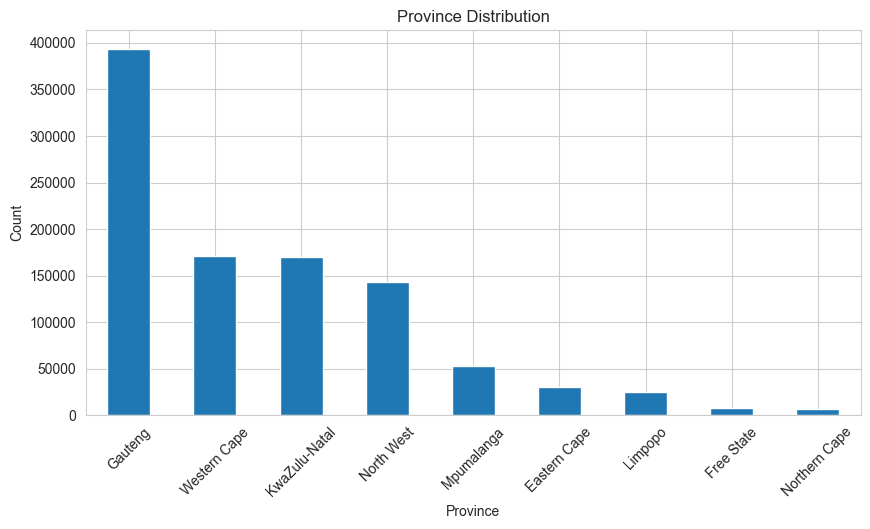

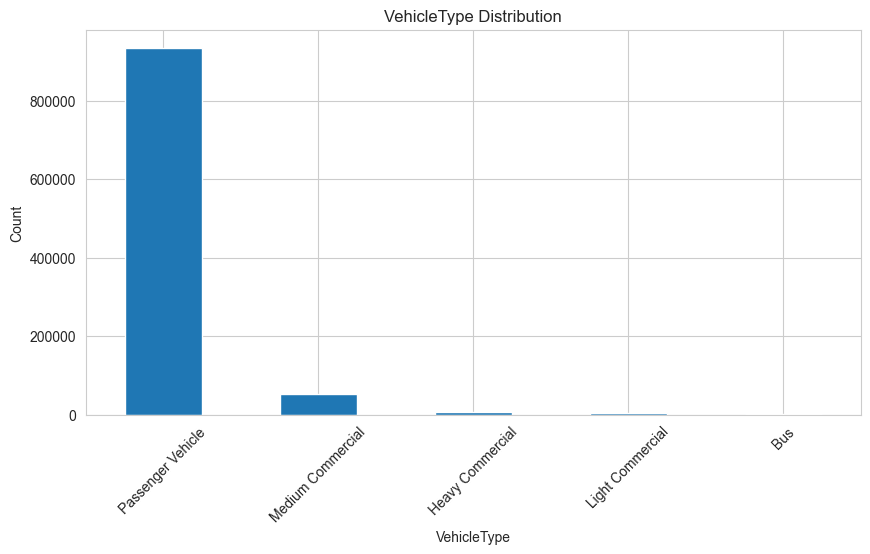

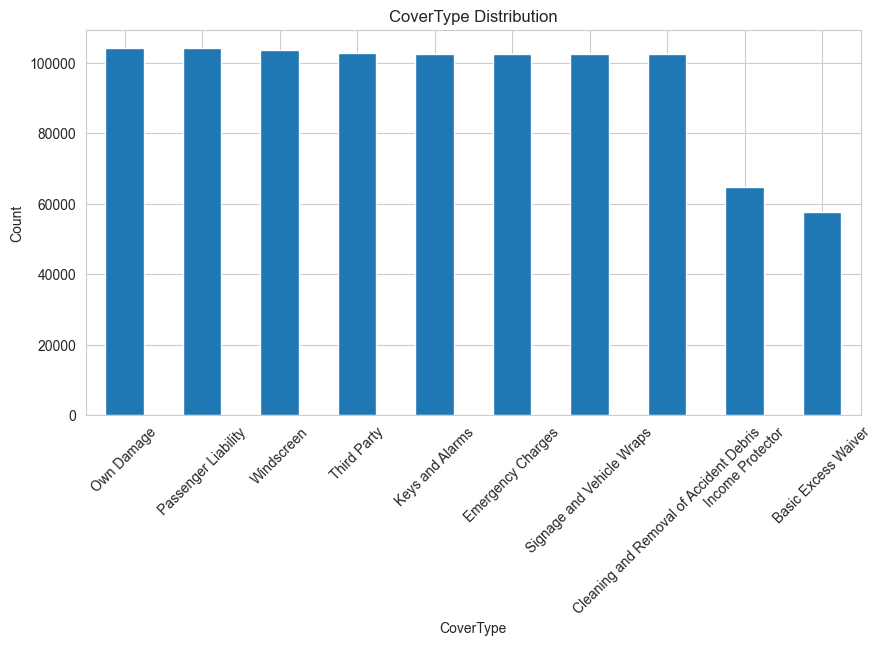

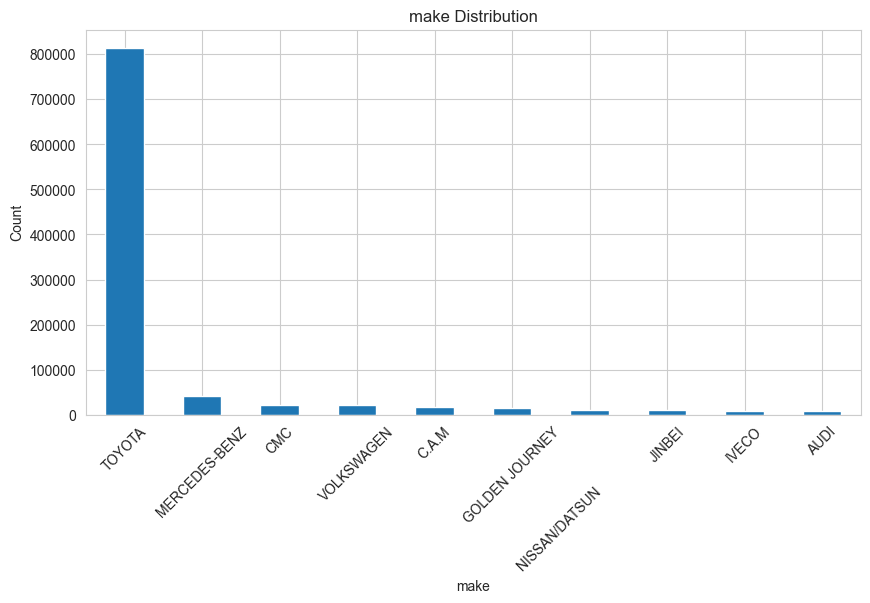

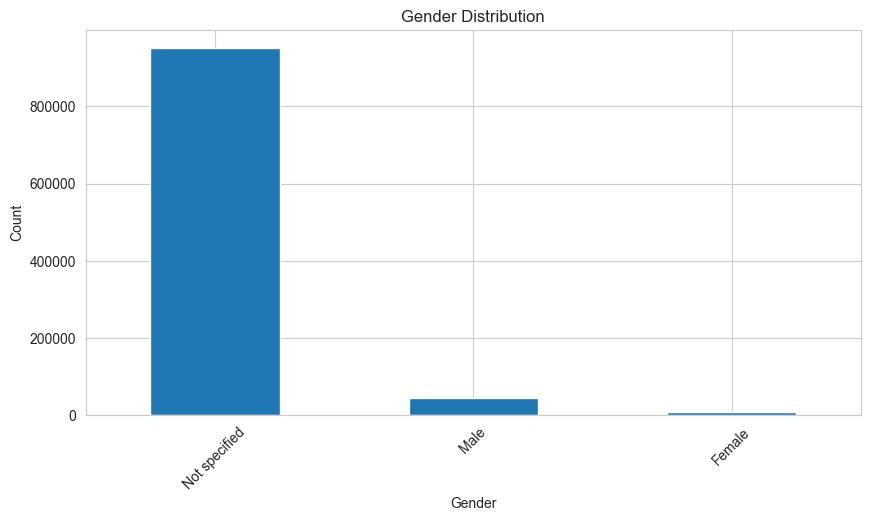

In [55]:
categorical_cols = [
    'Province',
    'VehicleType',
    'CoverType',
    'make',
    'Gender'
]
for col in categorical_cols:

        plt.figure(figsize=(10, 5))

        df[col].value_counts().head(10).plot(
            kind='bar'
        )

        plt.title(f'{col} Distribution')

        plt.xlabel(col)

        plt.ylabel('Count')

        plt.xticks(rotation=45)

        plt.show()

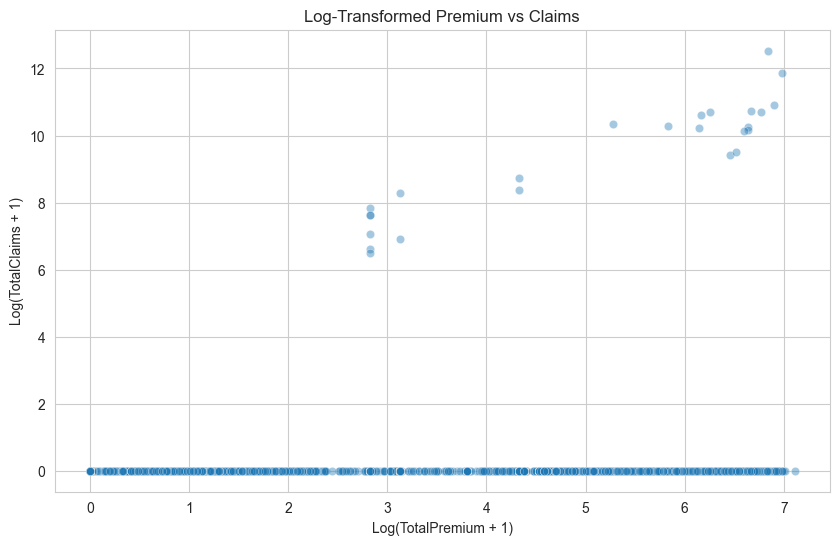

In [18]:
sample_df = df.sample(10000, random_state=42)

sample_df['LogPremium'] = np.log1p(
    sample_df['TotalPremium'].clip(lower=0)
)

sample_df['LogClaims'] = np.log1p(
    sample_df['TotalClaims'].clip(lower=0)
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x='LogPremium',
    y='LogClaims',
    alpha=0.4
)

plt.title('Log-Transformed Premium vs Claims')

plt.xlabel('Log(TotalPremium + 1)')

plt.ylabel('Log(TotalClaims + 1)')

plt.show()

In [ ]:
df

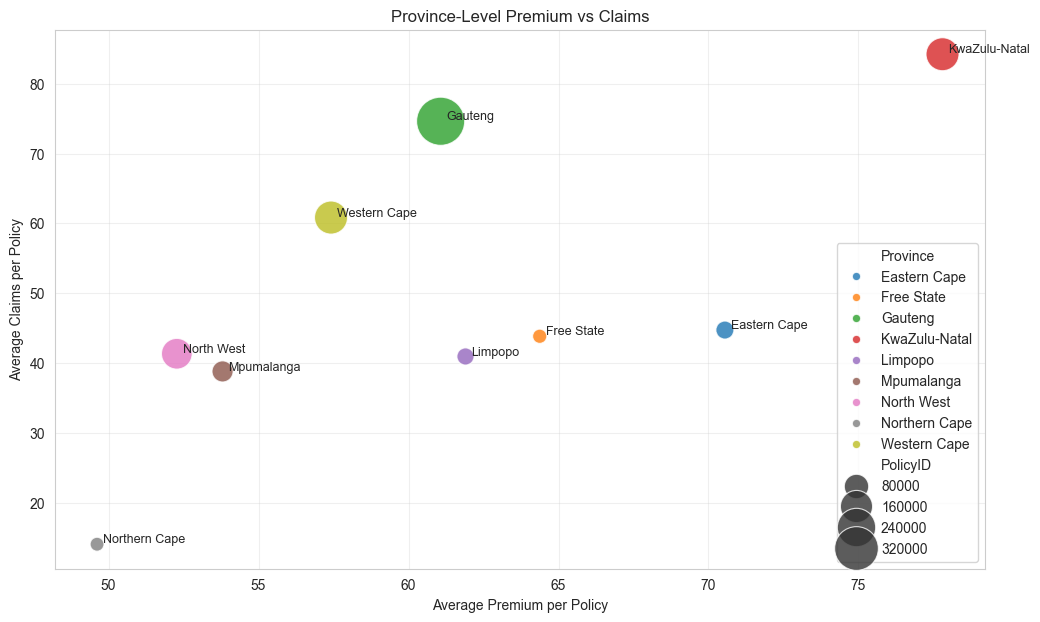

In [25]:
province_summary = df.groupby('Province').agg({
    'TotalPremium': 'mean',
    'TotalClaims': 'mean',
    'PolicyID': 'count'
}).reset_index()
plt.figure(figsize=(12,7))

scatter = sns.scatterplot(
    data=province_summary,
    x='TotalPremium',
    y='TotalClaims',
    size='PolicyID',
    hue='Province',
    sizes=(100, 1200),
    alpha=0.8
)

# Add province labels
for i, row in province_summary.iterrows():

    plt.text(
        row['TotalPremium'] + 0.2,
        row['TotalClaims'] + 0.2,
        row['Province'],
        fontsize=9
    )

plt.title('Province-Level Premium vs Claims')

plt.xlabel('Average Premium per Policy')

plt.ylabel('Average Claims per Policy')
plt.grid(alpha=0.3)

plt.show()

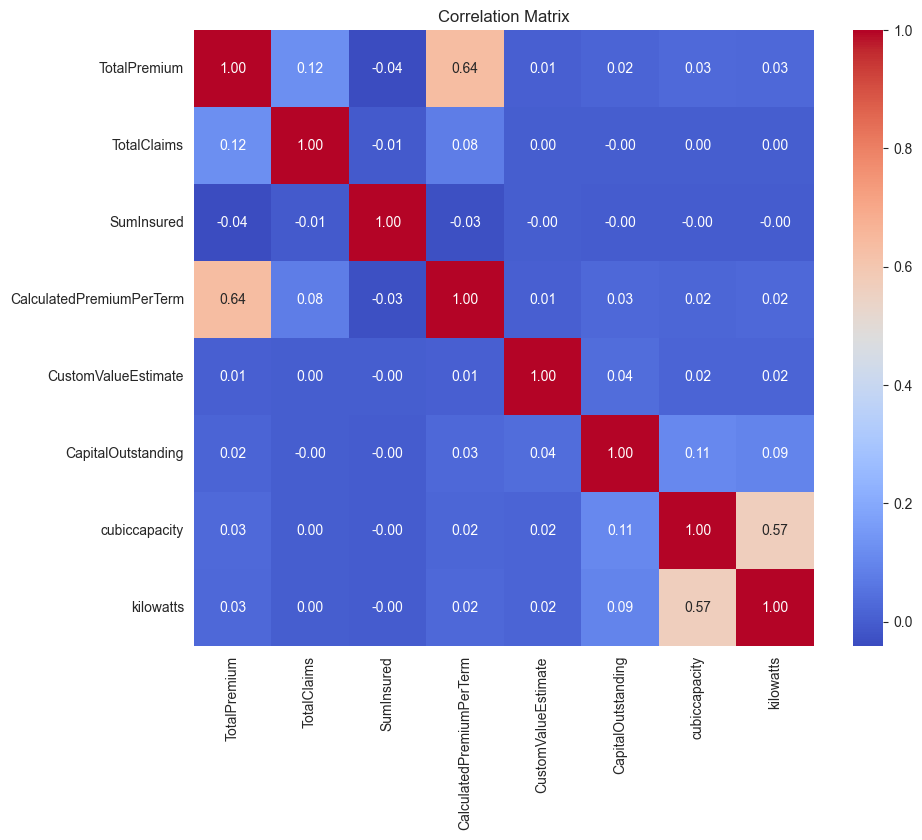

In [27]:
corr_cols = [
    'TotalPremium',
    'TotalClaims',
    'SumInsured',
    'CalculatedPremiumPerTerm',
    'CustomValueEstimate',
    'CapitalOutstanding',
    'cubiccapacity',
    'kilowatts'
]

# Compute correlation matrix
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

## Geographic Trends Analysis
### Average Premium Across Provinces

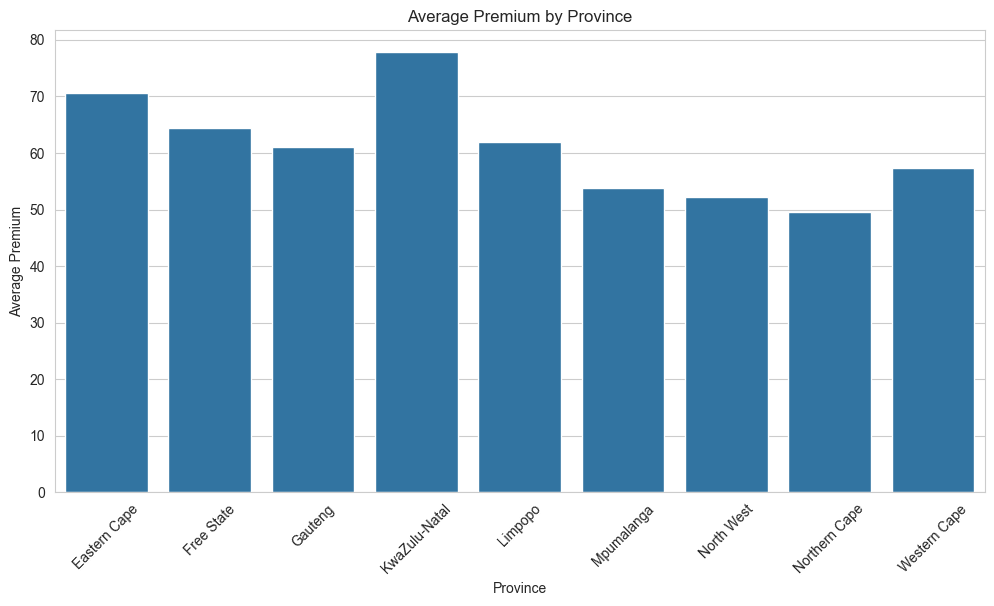

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average premium by province
province_premium = df.groupby('Province')[
    'TotalPremium'
].mean().reset_index()

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=province_premium,
    x='Province',
    y='TotalPremium'
)

plt.title('Average Premium by Province')

plt.xlabel('Province')

plt.ylabel('Average Premium')

plt.xticks(rotation=45)

plt.show()

### Cover Type Distribution Across Provinces

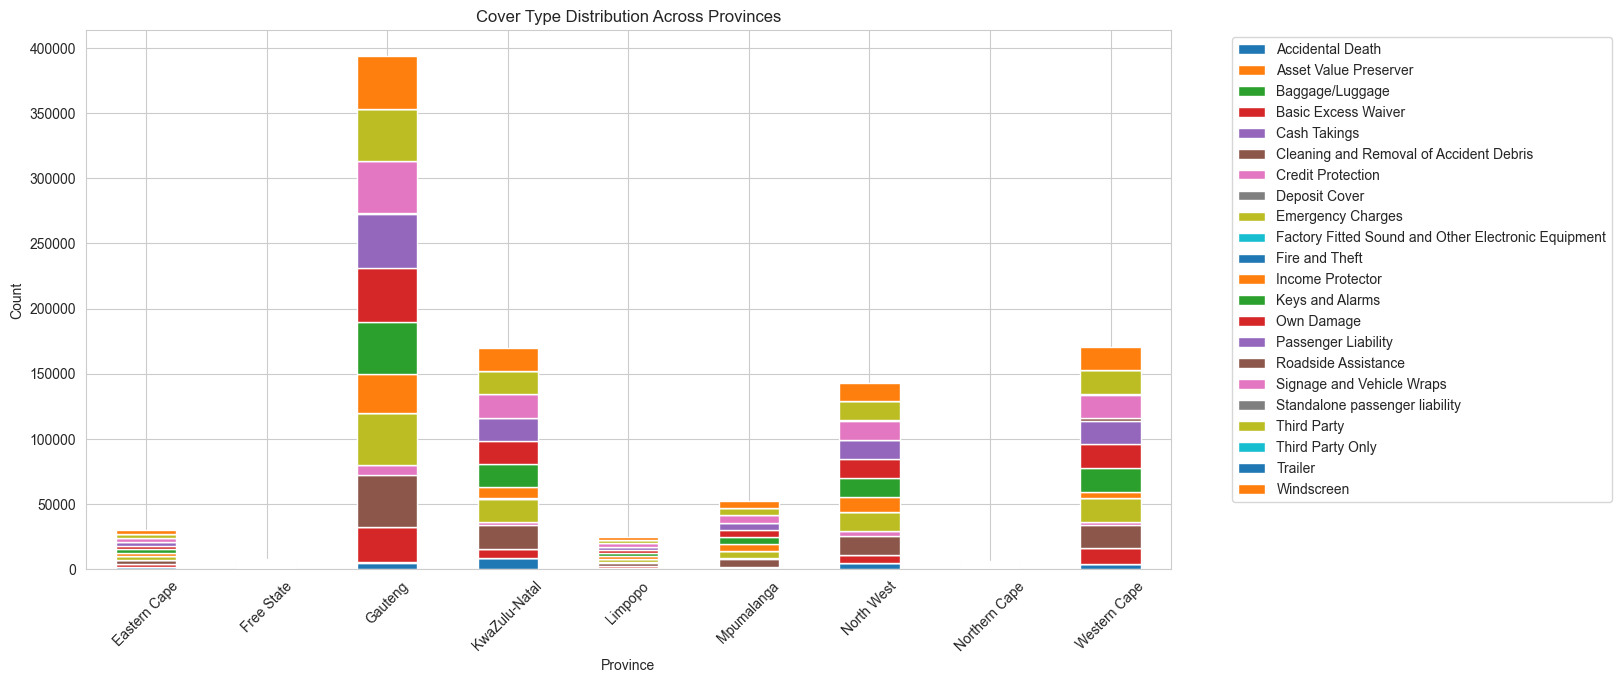

In [29]:
# Cross-tabulation
cover_province = pd.crosstab(
    df['Province'],
    df['CoverType']
)

# Plot
cover_province.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title('Cover Type Distribution Across Provinces')

plt.xlabel('Province')

plt.ylabel('Count')

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

### Auto Make Across Provinces

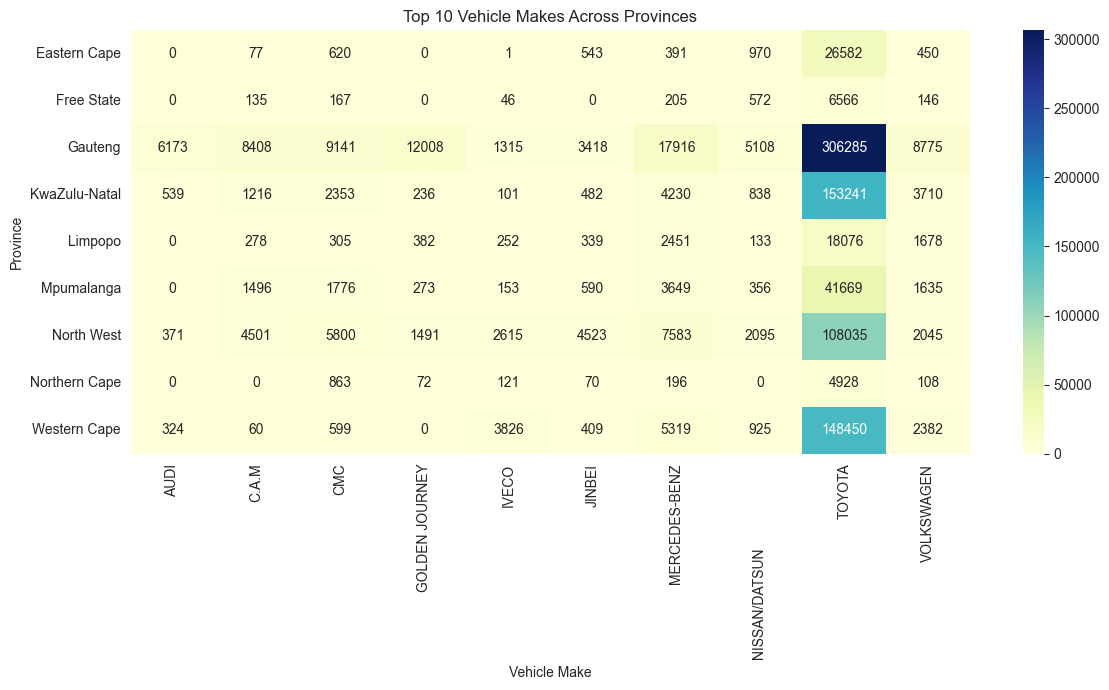

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select top 10 vehicle makes
top_makes = df['make'].value_counts().head(10).index

# Filter dataset
filtered_df = df[df['make'].isin(top_makes)]

# Create pivot table
heatmap_data = pd.crosstab(
    filtered_df['Province'],
    filtered_df['make']
)

# Plot heatmap
plt.figure(figsize=(12,7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='g',
    cmap='YlGnBu'
)

plt.title('Top 10 Vehicle Makes Across Provinces')

plt.xlabel('Vehicle Make')

plt.ylabel('Province')

plt.tight_layout()

plt.show()

Toyota was the most dominant vehicle make across all provinces, especially in Gauteng, KwaZulu-Natal, Western Cape, and North West.
Gauteng showed the highest concentration of vehicle policies overall, particularly for Toyota and Mercedes-Benz vehicles.
Western Cape and KwaZulu-Natal also contained substantial numbers of insured Toyota vehicles.
Luxury and commercial vehicle brands such as Mercedes-Benz appeared more concentrated in economically active provinces like Gauteng and North West.

## Outlier Detection

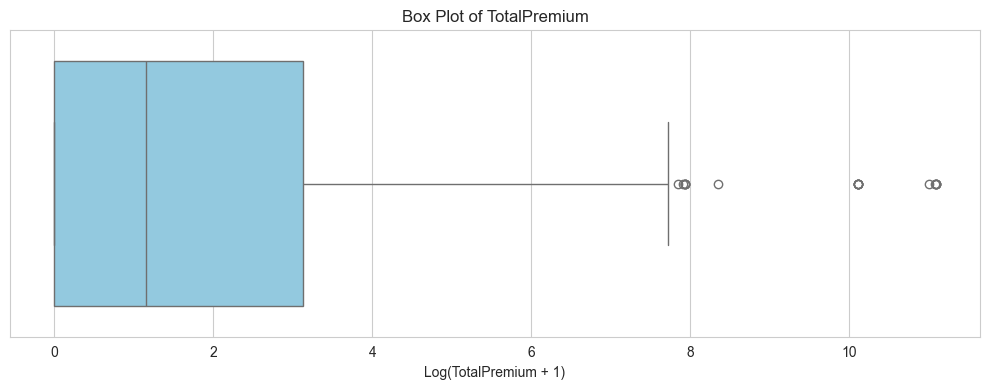

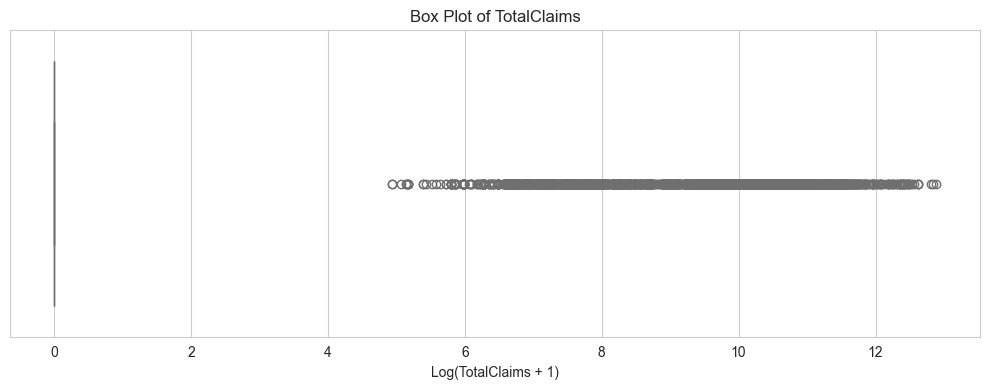

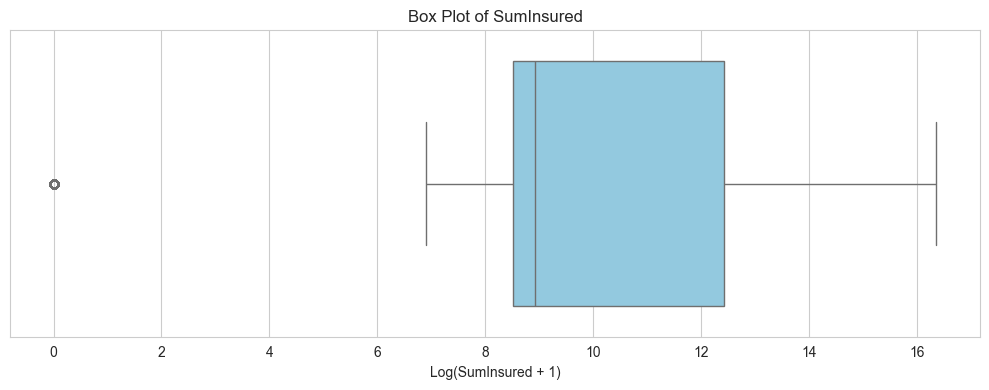

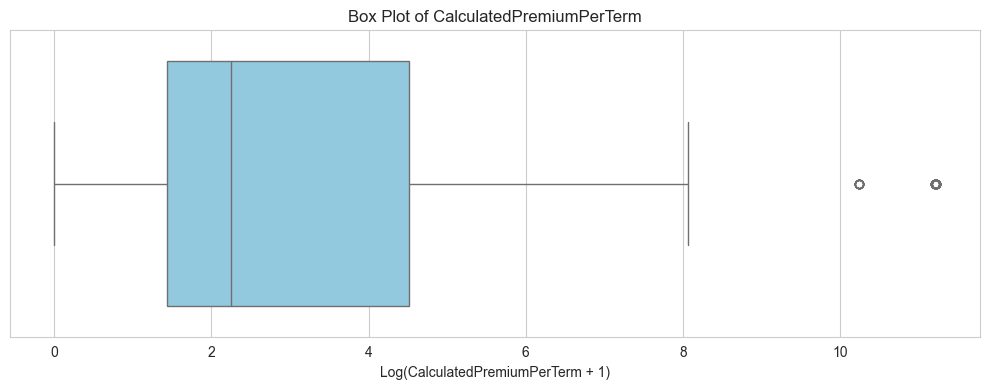

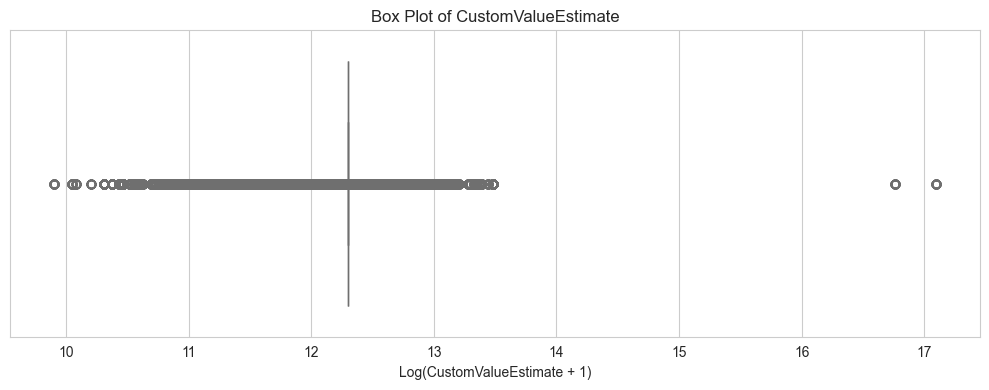

In [62]:
outlier_cols = [
    'TotalPremium',
    'TotalClaims',
    'SumInsured',
    'CalculatedPremiumPerTerm',
    'CustomValueEstimate'
]

# Create box plots
for col in outlier_cols:

    plt.figure(figsize=(10,4))

    sns.boxplot(
        x=np.log1p(df[col].clip(lower=0)),
        color='skyblue'
    )

    plt.title(f'Box Plot of {col}')

    plt.xlabel(f'Log({col} + 1)')

    plt.tight_layout()

    plt.show()

The key financial variables, including TotalPremium, TotalClaims, SumInsured, and CustomValueEstimate, exhibit highly right-skewed distributions. Most observations are concentrated at relatively low values, while a small number of records contain extremely large amounts. 

Significant outliers were identified in both TotalClaims and CustomValueEstimate through box plot analysis. TotalClaims contains a small number of exceptionally high claim amounts, while CustomValueEstimate includes very high-value insured vehicles compared to the majority of the portfolio. 

These extreme values can heavily influence summary statistics, correlations, and predictive models if left untreated. To improve visualization and reduce the effect of skewness, log transformations were applied during exploratory analysis.

## Overall Portfolio Loss Ratio

In [57]:
# Overall portfolio loss ratio
overall_loss_ratio = (
    df['TotalClaims'].sum() /
    df['TotalPremium'].sum()
)

print(f"Overall Loss Ratio: {overall_loss_ratio:.2f}")

Overall Loss Ratio: 1.05


The overall portfolio loss ratio is 1.05, indicating that total claims slightly exceeded total premium income during the analysis period. This suggests that the portfolio operated at a marginal underwriting loss, where claim costs were slightly higher than the premiums collected. A loss ratio above 1.0 may indicate the need for pricing adjustments, improved risk segmentation, or stricter underwriting strategies to improve profitability.

## Loss Ratio by Province

In [58]:
# Province-level loss ratio
province_loss = df.groupby('Province')[[
    'TotalClaims',
    'TotalPremium'
]].sum()

province_loss['LossRatio'] = (
    province_loss['TotalClaims'] /
    province_loss['TotalPremium']
)

province_loss = province_loss.sort_values(
    by='LossRatio',
    ascending=False
)

display(province_loss[['LossRatio']])

,LossRatio
Province,
Gauteng,1.222018
KwaZulu-Natal,1.082693
Western Cape,1.059472
North West,0.790367
Mpumalanga,0.720897
Free State,0.680758
Limpopo,0.661199
Eastern Cape,0.633813
Northern Cape,0.282699


The province-level loss ratio analysis shows that Gauteng recorded the highest loss ratio (1.22), indicating claims exceeded premium income and suggesting higher insurance risk and lower profitability in the region. KwaZulu-Natal and Western Cape also showed loss ratios above 1.0, reflecting relatively high claims exposure. 

In contrast, provinces such as Northern Cape, Eastern Cape, and Limpopo recorded lower loss ratios, indicating stronger underwriting profitability and lower relative claims costs. Overall, the results highlight significant geographic differences in portfolio risk across provinces.

## Loss Ratio by Vehicle Type

In [60]:
vehicle_loss = df.groupby('VehicleType')[[
    'TotalClaims',
    'TotalPremium'
]].sum()

vehicle_loss['LossRatio'] = (
    vehicle_loss['TotalClaims'] /
    vehicle_loss['TotalPremium']
)

vehicle_loss = vehicle_loss.sort_values(
    by='LossRatio',
    ascending=False
)

display(vehicle_loss[['LossRatio']].head(10))

,LossRatio
VehicleType,
Heavy Commercial,1.628112
Medium Commercial,1.050251
Passenger Vehicle,1.047538
Light Commercial,0.232066
Bus,0.137292


The loss ratio varies significantly across vehicle types. Heavy Commercial vehicles recorded the highest loss ratio (1.63), indicating claims exceeded premium income and suggesting high insurance risk. Medium Commercial and Passenger Vehicle categories also showed loss ratios slightly above 1.0, reflecting lower profitability. In contrast, Light Commercial and Bus vehicles had much lower loss ratios, indicating stronger portfolio profitability and lower claims exposure.

## Loss Ratio by Gender

In [61]:
gender_loss = df.groupby('Gender')[[
    'TotalClaims',
    'TotalPremium'
]].sum()

gender_loss['LossRatio'] = (
    gender_loss['TotalClaims'] /
    gender_loss['TotalPremium']
)

display(gender_loss[['LossRatio']])

,LossRatio
Gender,
Female,0.821879
Male,0.883910
Not specified,1.053204


Differences in loss ratios between genders may reflect variations in driving behavior, vehicle usage patterns, or exposure levels, although further statistical testing would be required to confirm whether these differences are significant.

## Temporal Trend Analysis
### Monthly Claim Frequency

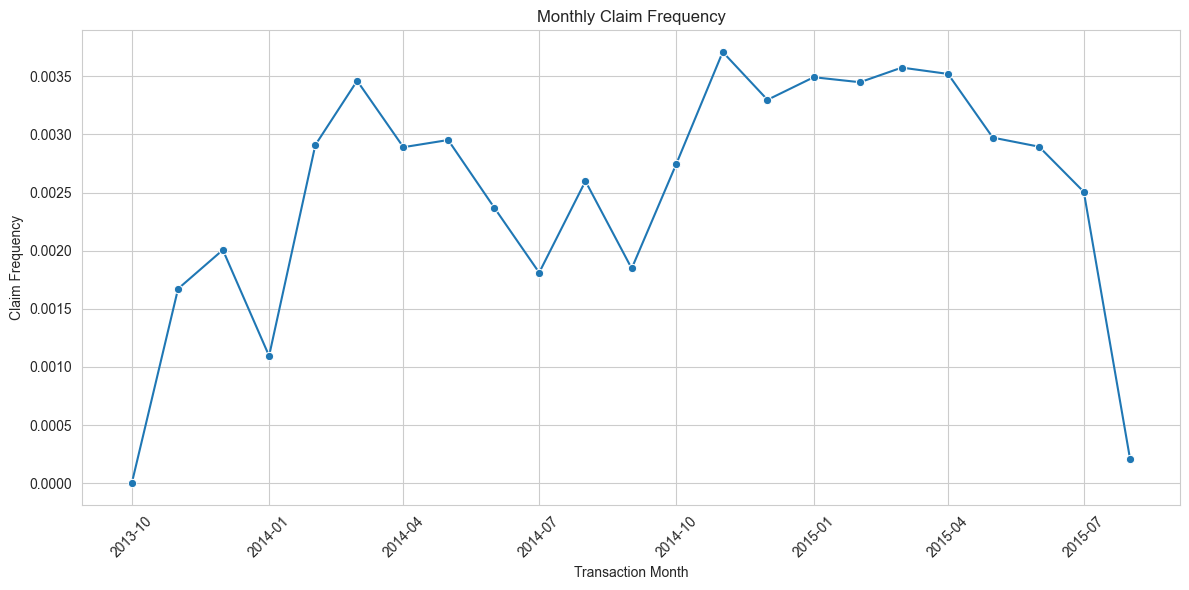

In [63]:
# Create claim indicator
df['HasClaim'] = df['TotalClaims'] > 0

# Monthly claim frequency
claim_frequency = df.groupby(
    'TransactionMonth'
)['HasClaim'].mean().reset_index()

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=claim_frequency,
    x='TransactionMonth',
    y='HasClaim',
    marker='o'
)

plt.title('Monthly Claim Frequency')

plt.xlabel('Transaction Month')

plt.ylabel('Claim Frequency')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The temporal trend analysis shows that claim frequency remained relatively stable throughout most of the 18-month period, with only moderate fluctuations over time.

### Monthly Claim Severity

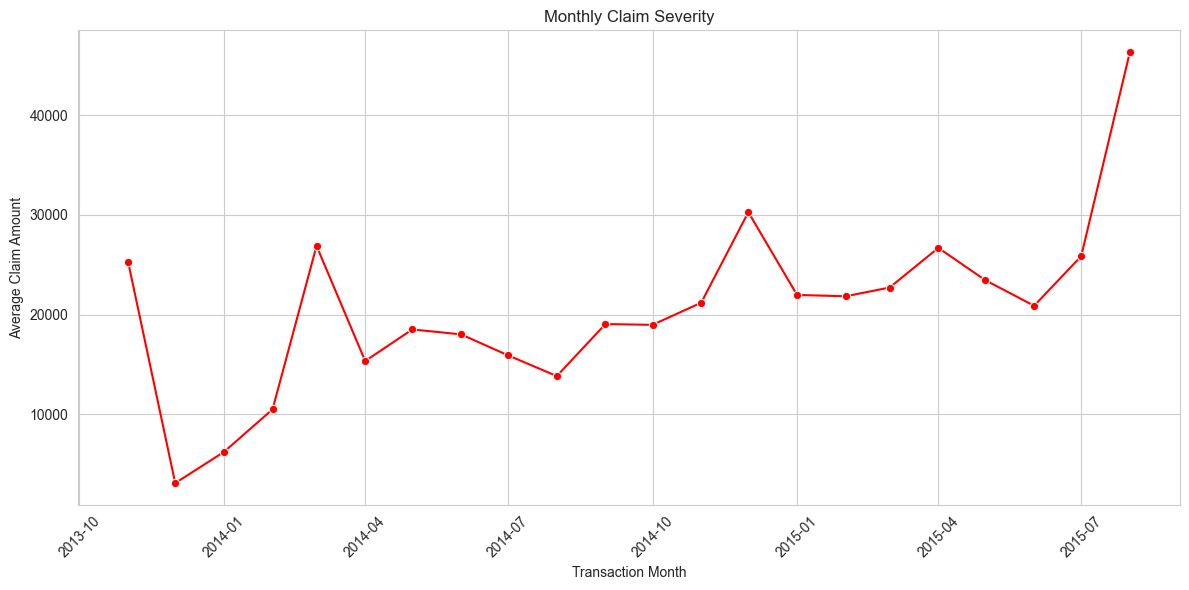

In [64]:
# Filter non-zero claims
claims_only = df[df['TotalClaims'] > 0]

# Monthly claim severity
claim_severity = claims_only.groupby(
    'TransactionMonth'
)['TotalClaims'].mean().reset_index()

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=claim_severity,
    x='TransactionMonth',
    y='TotalClaims',
    marker='o',
    color='red'
)

plt.title('Monthly Claim Severity')

plt.xlabel('Transaction Month')

plt.ylabel('Average Claim Amount')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Claim severity showed greater variability over time. Several months experienced noticeable spikes in average claim amounts, particularly toward mid-2015, indicating the occurrence of a few high-cost claims. The sharp increase in claim severity near the end of the period suggests that while claims were not necessarily more frequent, the financial impact of individual claims became significantly larger during certain months.

## Average Claim Amount by Vehicle Make

In [65]:
# Average claim amount by vehicle make
make_claims = df.groupby('make')[
    'TotalClaims'
].mean().sort_values(ascending=False)

# Highest average claims
highest_make_claims = make_claims.head(10)

# Lowest average claims
lowest_make_claims = make_claims.tail(10)

print("Highest Claim Vehicle Makes")
display(highest_make_claims)

print("\nLowest Claim Vehicle Makes")
display(lowest_make_claims)

Highest Claim Vehicle Makes


make
SUZUKI                                 419.634546
JMC                                    191.684795
HYUNDAI                                174.215195
MARCOPOLO                              156.794806
AUDI                                   137.843083
POLARSUN                               134.044800
B.A.W                                  132.934016
FIAT                                   108.625642
BMW                                     90.558050
IVECO                                   89.667017
Name: TotalClaims, dtype: float64


Lowest Claim Vehicle Makes


make
HINO                                   0.0
JINBEI                                 0.0
LEXUS                                  0.0
PROTON                                 0.0
PEUGEOT                                0.0
OPEL                                   0.0
RENAULT                                0.0
SCANIA                                 0.0
TATA                                   0.0
VOLVO                                  0.0
Name: TotalClaims, dtype: float64

## Average Claim Amount by Vehicle Model

In [66]:
# Average claim amount by vehicle model
model_claims = df.groupby('Model')[
    'TotalClaims'
].mean().sort_values(ascending=False)

# Highest average claims
highest_model_claims = model_claims.head(10)

# Lowest average claims
lowest_model_claims = model_claims.tail(10)

print("Highest Claim Vehicle Models")
display(highest_model_claims)

print("\nLowest Claim Vehicle Models")
display(lowest_model_claims)

Highest Claim Vehicle Models


Model
L/CRUISER FJ 4.0 V6 CRUISER    5340.970273
H-1 2.5 CRDI WAGON A/T         4118.181043
DUCATO 2.3 JTD VETRATO         1014.681021
POLO VIVO 1.6 5Dr               827.558882
C180 BE COUPE                   743.459027
SPRINTER 312D F/C P/V           664.540138
ERTIGA 1.4 GA                   631.774519
YARIS T1 3Dr                    618.719846
A4 1.8T S AVANT MULTITRONIC     480.282859
POLO 1.6 COMFORTLINE            431.842105
Name: TotalClaims, dtype: float64


Lowest Claim Vehicle Models


Model
323 130 STING                        0.000000
YARIS 1.3 5Dr                        0.000000
YARIS T1 5Dr                         0.000000
YARIS T3 A/C                         0.000000
YARIS T3 SPIRIT 5Dr                  0.000000
YARIS T3+                            0.000000
YARIS ZEN3                           0.000000
T5 CARAVELLE 2.0 BiTDi               0.000000
115 VITO 2.2 CDI CREW CAB F/C P/V    0.000000
C200K CLASSIC A/T                   -0.250832
Name: TotalClaims, dtype: float64

The vehicle make and model analysis showed that luxury, commercial, and high-value vehicles generally had the highest average claim amounts. Models such as L/CRUISER FJ 4.0 V6 CRUISER and H-1 2.5 CRDI WAGON A/T recorded the highest claims, while vehicle makes such as SUZUKI, JMC, and HYUNDAI also showed relatively high average claim amounts.

Premium brands including AUDI and BMW exhibited elevated claim severity, suggesting that vehicle value, repair costs, and usage patterns strongly influence insurance claims.

## Province-Level Premium vs Claims Bubble Plot

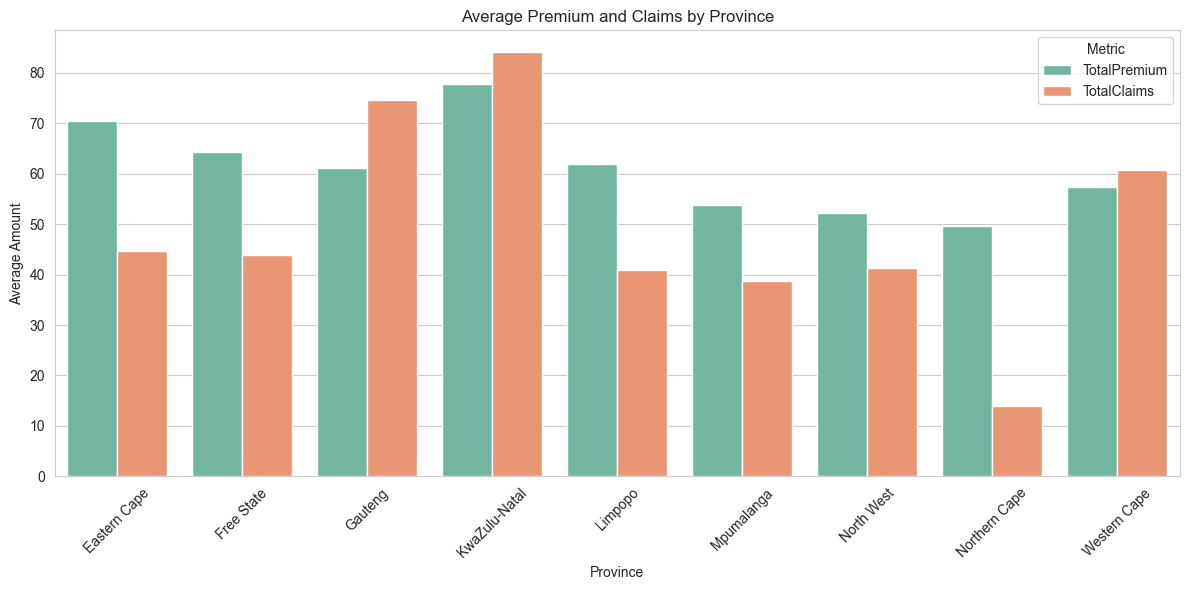

In [69]:
import pandas as pd

# Reshape data
plot_data = province_summary.melt(
    id_vars='Province',
    value_vars=['TotalPremium', 'TotalClaims'],
    var_name='Metric',
    value_name='Value'
)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=plot_data,
    x='Province',
    y='Value',
    hue='Metric',
    palette='Set2'
)

plt.title('Average Premium and Claims by Province')

plt.xlabel('Province')

plt.ylabel('Average Amount')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The chart shows that KwaZulu-Natal recorded both the highest average premiums and claims, indicating higher insurance risk and claim exposure. Gauteng and Western Cape also showed relatively high claim amounts compared to other provinces. In contrast, Northern Cape recorded the lowest average claims and premiums, suggesting lower portfolio exposure and stronger profitability.

## Loss Ratio by Province

C:\Users\bemnet\AppData\Local\Temp\ipykernel_18584\3146162954.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


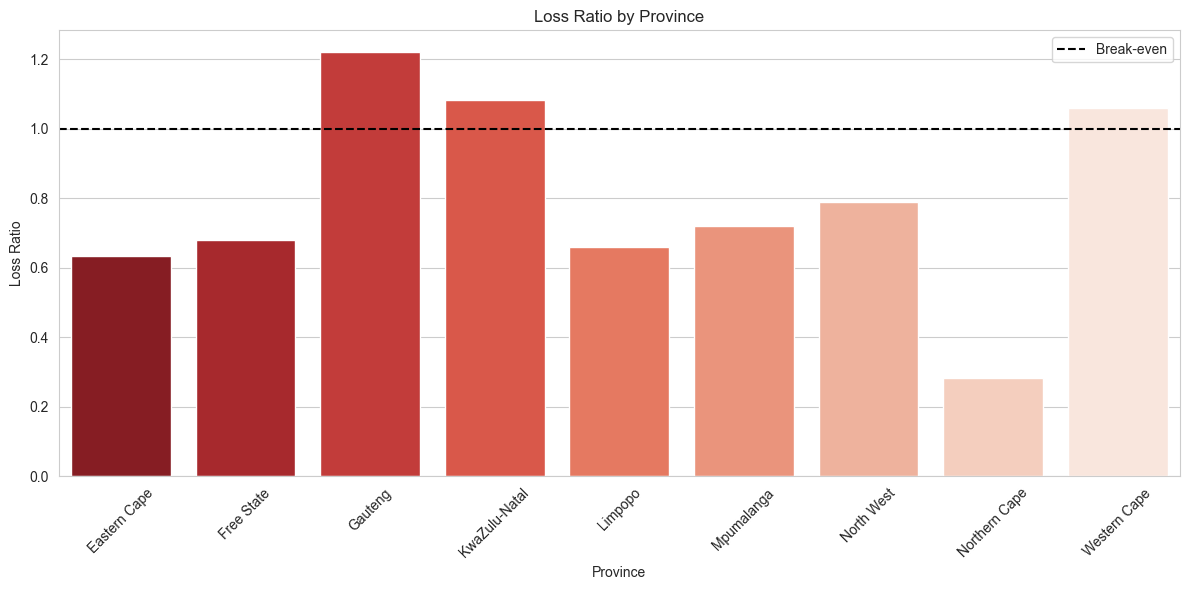

In [68]:
# Calculate loss ratio
province_loss = df.groupby('Province')[[
    'TotalClaims',
    'TotalPremium'
]].sum()

province_loss['LossRatio'] = (
    province_loss['TotalClaims'] /
    province_loss['TotalPremium']
)

province_loss = province_loss.sort_values(
    by='LossRatio',
    ascending=False
)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=province_loss.index,
    y=province_loss['LossRatio'],
    palette='Reds_r'
)

plt.axhline(
    y=1,
    color='black',
    linestyle='--',
    label='Break-even'
)

plt.title('Loss Ratio by Province')

plt.xlabel('Province')

plt.ylabel('Loss Ratio')

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

The loss ratio varies significantly across provinces. Gauteng recorded the highest loss ratio, indicating claims exceeded premium income and suggesting higher insurance risk. KwaZulu-Natal and Western Cape also showed relatively high loss ratios, while Northern Cape had the lowest loss ratio, indicating stronger profitability and lower claims exposure. Overall, the results highlight important geographic differences in portfolio risk and underwriting performance.

## Loss Ratio by Vehicle Type

C:\Users\bemnet\AppData\Local\Temp\ipykernel_18800\1871698500.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


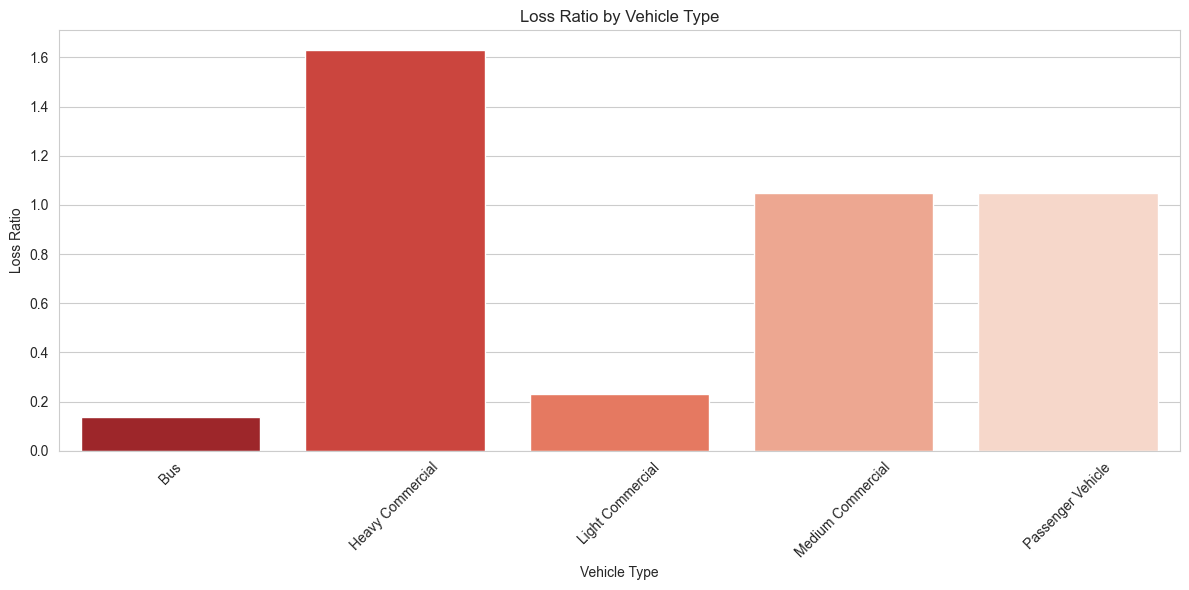

In [21]:
vehicle_loss = df.groupby('VehicleType')[[
    'TotalClaims',
    'TotalPremium'
]].sum()

vehicle_loss['LossRatio'] = (
    vehicle_loss['TotalClaims'] /
    vehicle_loss['TotalPremium']
)

vehicle_loss = vehicle_loss.sort_values(
    by='LossRatio',
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=vehicle_loss.index,
    y=vehicle_loss['LossRatio'],
    palette='Reds_r'
)

plt.title('Loss Ratio by Vehicle Type')

plt.xlabel('Vehicle Type')

plt.ylabel('Loss Ratio')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The loss ratio varies substantially across vehicle types, indicating significant differences in insurance risk and profitability. Heavy Commercial vehicles recorded the highest loss ratio (above 1.6), meaning claims exceeded premium income and suggesting this segment is highly unprofitable and high-risk. Medium Commercial and Passenger Vehicle categories also showed loss ratios slightly above 1.0, indicating relatively high claims exposure and lower underwriting profitability.

In contrast, Bus and Light Commercial vehicles recorded much lower loss ratios, suggesting stronger profitability and lower relative claims costs. Overall, the results highlight vehicle type as an important factor in risk segmentation and pricing strategy.

## Claim Frequency by Province

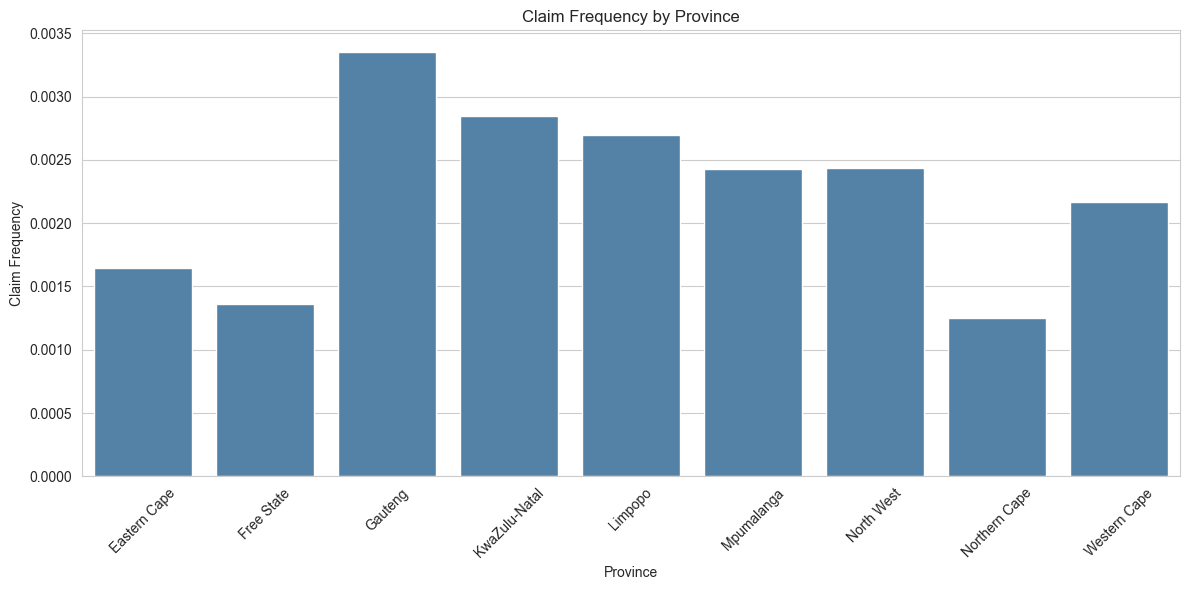

In [23]:
# Create claim indicator
df['HasClaim'] = (
    df['TotalClaims'] > 0
).astype(int)

# Claim frequency
province_frequency = df.groupby('Province')[
    'HasClaim'
].mean().sort_values(
    ascending=False
)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=province_frequency.index,
    y=province_frequency.values,
    color='steelblue'
)

plt.title('Claim Frequency by Province')

plt.xlabel('Province')

plt.ylabel('Claim Frequency')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The analysis shows that insurance risk is not evenly distributed across geographic regions.

### Higher-Risk Provinces
- **Gauteng**, **KwaZulu-Natal**, and **Limpopo** recorded higher claim frequencies.
- Policies in these regions are more likely to generate claims, indicating increased insurance risk exposure.

### Business Implications
These provinces may require:
- stricter underwriting policies
- higher premium pricing
- targeted risk management strategies

to maintain portfolio profitability.

### Lower-Risk Provinces
- **Northern Cape** and **Free State** recorded lower claim frequencies.
- These regions represent comparatively lower-risk and potentially more profitable customer segments.

### Strategic Opportunities
Lower-risk provinces may provide opportunities for:
- competitive pricing
- customer acquisition campaigns
- premium reductions for low-risk policyholders

### Overall Business Impact
The findings support the use of **geographic risk segmentation** to improve pricing accuracy, underwriting decisions, and overall portfolio performance.

## Margin Analysis
Margin = TotalPremium − TotalClaims


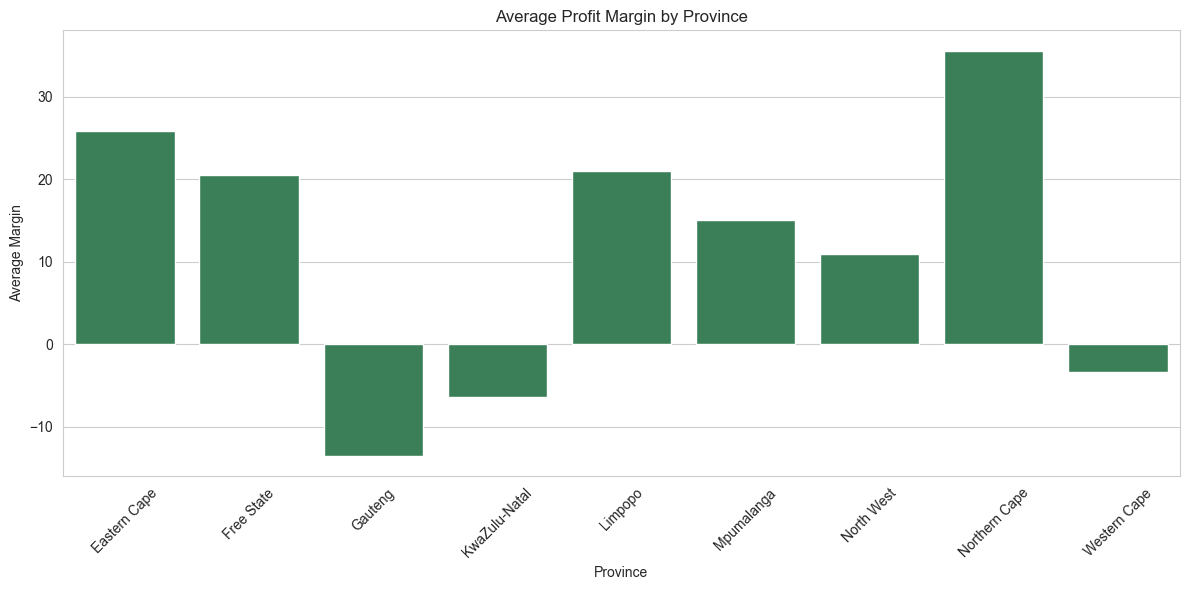

In [26]:
# Calculate margin
df['Margin'] = (
    df['TotalPremium'] -
    df['TotalClaims']
)

# Province margin
province_margin = df.groupby('Province')[
    'Margin'
].mean().sort_values(
    ascending=False
)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=province_margin.index,
    y=province_margin.values,
    color='seagreen'
)

plt.title('Average Profit Margin by Province')

plt.xlabel('Province')

plt.ylabel('Average Margin')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The profit margin analysis highlights clear differences in underwriting profitability across provinces.

### High-Profit Provinces
- **Northern Cape** recorded the highest average profit margin, indicating strong profitability and lower claims exposure.
- **Eastern Cape**, **Limpopo**, and **Free State** also showed positive margins, suggesting relatively stable and profitable insurance portfolios.

### Low-Profit Provinces
- **Gauteng**, **KwaZulu-Natal**, and **Western Cape** recorded negative average margins, meaning claims exceeded premium income in these regions.
- These provinces may require:
  - premium adjustments
  - stricter underwriting policies
  - enhanced risk management strategies

### Overall Business Impact
The results demonstrate that profitability varies significantly across geographic regions. This supports the use of **province-level risk segmentation** to improve pricing accuracy, underwriting decisions, and overall portfolio performance.